# PSO Benchmark Analysis

Análisis comparativo de cuatro estrategias de evaluación de fitness en PSO sobre funciones benchmark estándar.

**Evaluadores comparados:** sequential (V0) · threading (V1) · multiprocessing (V2) · asyncio (V3)  
**Funciones:** sphere · rastrigin · rosenbrock · ackley  
**Dimensiones:** 2 · 10 · 30  
**Seeds:** 42 · 43 · 44 · 45 · 46

El núcleo PSO es idéntico en las cuatro variantes — solo cambia cómo se evalúa el fitness de cada partícula. Dado que el mismo seed produce el mismo resultado independientemente del evaluador, **la calidad de la solución es siempre idéntica**. La única diferencia relevante es el **tiempo de ejecución** y, en el caso de asyncio, la capacidad de solapar evaluaciones I/O-bound.

Las secciones 2–5 comparan los cuatro evaluadores sobre los benchmarks estándar. La sección 6 analiza asyncio de forma independiente, incluyendo su caso de uso específico con latencias simuladas.

## Metodología experimental

Se comparan cuatro estrategias de evaluación de fitness sobre el mismo núcleo PSO canónico:

| Variante | Implementación |
|---|---|
| **V0 Sequential** | Bucle Python puro — baseline |
| **V1 Threading** | `ThreadPoolExecutor` con pool reutilizado entre iteraciones |
| **V2 Multiprocessing** | `ProcessPoolExecutor` con pool reutilizado + `chunksize` batching |
| **V3 Asyncio** | `asyncio.gather` (y otras estrategias) con event loop reutilizado; simula latencias I/O por partícula |

El núcleo PSO es idéntico en las cuatro variantes: solo cambia el evaluador de fitness, inyectado como dependencia. Esto garantiza que cualquier diferencia de rendimiento sea atribuible exclusivamente al mecanismo de paralelización.

**Nota sobre asyncio**: la concurrencia cooperativa de asyncio no acelera cómputo CPU-bound puro. Su ventaja aparece cuando la evaluación del fitness implica esperas (I/O, latencia de red, simuladores externos). El `AsyncioEvaluator` permite simular este escenario mediante los parámetros `latency_s` y `jitter`. Con `latency_s=0` (benchmark estándar), los tiempos serán mayores que el secuencial por el overhead del event loop.

## 1. Setup

Se importan las librerías necesarias y se cargan los CSV más recientes generados por `run_benchmarks.py`. Cada fila del summary corresponde a una ejecución completa del PSO (combinación de función objetivo, dimensión, evaluador y seed). El archivo de historial contiene el mejor fitness por iteración para cada ejecución.

In [25]:
import os
import glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

# Detect project root: notebook lives in docs/, so go up one level
_cwd = Path.cwd()
project_root = _cwd.parent if _cwd.name == "docs" else _cwd
os.chdir(project_root)

benchmark_dir = project_root / "results" / "benchmarks"
summary_files = sorted(benchmark_dir.glob("summary_*.csv"))
history_files = sorted(benchmark_dir.glob("history_*.csv"))

if not summary_files:
    raise FileNotFoundError(
        f"No se encontraron CSVs en {benchmark_dir}.\n"
        "Ejecuta primero:  python run_benchmarks.py"
    )

summary = pd.read_csv(summary_files[-1])
history = pd.read_csv(history_files[-1])

objectives = sorted(summary["objective"].unique())
dims = sorted(summary["dimension"].unique())
evaluators = sorted(summary["evaluator"].unique())

print(f"Summary: {len(summary)} runs  |  History: {len(history)} rows")
print(f"\nEvaluators: {evaluators}")
print(f"Objectives: {objectives}")
print(f"Dimensions: {dims}")
summary.head()

Summary: 240 runs  |  History: 48000 rows

Evaluators: ['asyncio', 'multiprocessing', 'sequential', 'threading']
Objectives: ['ackley', 'rastrigin', 'rosenbrock', 'sphere']
Dimensions: [np.int64(2), np.int64(10), np.int64(30)]


,run_id,objective,dimension,evaluator,seed,inertia_weight,cognitive_weight,social_weight,swarm_size,best_value,total_time_s,total_eval_time_s,total_update_time_s,converged_iteration,total_iterations
0,sphere_sequential_d2_seed42,sphere,2,sequential,42,0.7,1.5,1.5,30,3.069943e-25,0.047883,0.011255,0.035480,NaN,200
1,sphere_sequential_d2_seed43,sphere,2,sequential,43,0.7,1.5,1.5,30,2.831461e-27,0.047916,0.011211,0.035509,NaN,200
2,sphere_sequential_d2_seed44,sphere,2,sequential,44,0.7,1.5,1.5,30,1.871387e-24,0.047638,0.011192,0.035355,NaN,200
3,sphere_sequential_d2_seed45,sphere,2,sequential,45,0.7,1.5,1.5,30,3.542791e-24,0.047683,0.011222,0.035372,NaN,200
4,sphere_sequential_d2_seed46,sphere,2,sequential,46,0.7,1.5,1.5,30,4.006753e-24,0.047675,0.011269,0.035305,NaN,200


In [26]:
print(f"Runs cargados   : {len(summary)}")
print(f"Evaluadores     : {evaluators}")
print(f"Funciones       : {objectives}")
print(f"Dimensiones     : {list(dims)}")
print(f"Seeds por combo : {summary['seed'].nunique()}")
print()
# Check that all evaluators produce identical fitness for same seed
pivot = summary.pivot_table(index=["objective","dimension","seed"],
                             columns="evaluator", values="best_value")
diffs = (pivot.max(axis=1) - pivot.min(axis=1)).abs()
print(f"Diferencia máxima de fitness entre evaluadores (mismo seed): {diffs.max():.2e}")
print("→ Los tres evaluadores producen resultados idénticos (mismo seed = mismo resultado).")

Runs cargados   : 240
Evaluadores     : ['asyncio', 'multiprocessing', 'sequential', 'threading']
Funciones       : ['ackley', 'rastrigin', 'rosenbrock', 'sphere']
Dimensiones     : [np.int64(2), np.int64(10), np.int64(30)]
Seeds por combo : 5

Diferencia máxima de fitness entre evaluadores (mismo seed): 0.00e+00
→ Los tres evaluadores producen resultados idénticos (mismo seed = mismo resultado).


**Interpretación.** Los experimentos confirman que el diseño es correcto: al fijar la misma semilla, los tres evaluadores producen exactamente el mismo resultado numérico. Cualquier diferencia de rendimiento que observemos es debida exclusivamente al mecanismo de paralelización, no a diferencias en la calidad de la optimización.

In [27]:
import platform, os

# PSO configuration (from CSV — all runs use the same hyperparameters)
cfg_row = summary.iloc[0]
print("=== Configuración PSO ===")
print(f"  Inercia (w)        : {cfg_row['inertia_weight']}")
print(f"  Cognitivo (c1)     : {cfg_row['cognitive_weight']}")
print(f"  Social (c2)        : {cfg_row['social_weight']}")
print(f"  Tamaño del enjambre: {int(cfg_row['swarm_size'])}")
print(f"  Máx. iteraciones   : {int(summary['total_iterations'].max())}")
print(f"  Topología          : Global best (gbest)")
print(f"  Política de límites: Clamp + zeroing de velocidad")

print()
print("=== Protocolo experimental ===")
print(f"  Funciones objetivo : {objectives}")
print(f"  Dimensiones        : {list(dims)}")
print(f"  Evaluadores        : {evaluators}")
print(f"  Seeds              : {sorted(summary['seed'].unique().tolist())}")
print(f"  Runs totales       : {len(summary)}")

print()
print("=== Entorno de ejecución ===")
print(f"  Sistema operativo  : {platform.platform()}")
print(f"  Python             : {platform.python_version()}")
print(f"  CPUs disponibles   : {os.cpu_count()}")
print()
print("=== Workers por evaluador (max_workers=None → Python elige) ===")
import os
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
with ThreadPoolExecutor() as t:
    print(f"  threading        : {t._max_workers} workers  (min(32, cpu_count + 4))")
with ProcessPoolExecutor() as p:
    print(f"  multiprocessing  : {p._max_workers} workers  (cpu_count)")
print()
print("=== Configuración de workers en este experimento ===")
swarm_size = int(summary["swarm_size"].iloc[0])
max_w = 4  # fijado en configs/benchmarks.yaml
print(f"  max_workers        : {max_w}")
print(f"  swarm_size         : {swarm_size}")
print(f"  Partículas/worker  : {swarm_size / max_w:.1f}")
print(f"  (Python default sería {__import__('os').cpu_count()} procesos o {min(32, __import__('os').cpu_count()+4)} hilos)")

=== Configuración PSO ===
  Inercia (w)        : 0.7
  Cognitivo (c1)     : 1.5
  Social (c2)        : 1.5
  Tamaño del enjambre: 30
  Máx. iteraciones   : 200
  Topología          : Global best (gbest)
  Política de límites: Clamp + zeroing de velocidad

=== Protocolo experimental ===
  Funciones objetivo : ['ackley', 'rastrigin', 'rosenbrock', 'sphere']
  Dimensiones        : [np.int64(2), np.int64(10), np.int64(30)]
  Evaluadores        : ['asyncio', 'multiprocessing', 'sequential', 'threading']
  Seeds              : [42, 43, 44, 45, 46]
  Runs totales       : 240

=== Entorno de ejecución ===
  Sistema operativo  : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
  Python             : 3.12.3
  CPUs disponibles   : 20

=== Workers por evaluador (max_workers=None → Python elige) ===
  threading        : 24 workers  (min(32, cpu_count + 4))
  multiprocessing  : 20 workers  (cpu_count)

=== Configuración de workers en este experimento ===
  max_workers        : 4
  swarm_

## 2. Curvas de convergencia

Fitness medio por iteración (media sobre seeds). Como el seed es idéntico, todos los evaluadores producen el mismo fitness — solo se muestra la curva de `sequential`.

Se representan las curvas de convergencia medias (promediadas sobre las 5 seeds) para cada combinación de función objetivo, dimensión y evaluador. El objetivo es comprobar si el mecanismo de paralelización afecta a la trayectoria de optimización o si los tres evaluadores convergen de forma idéntica.

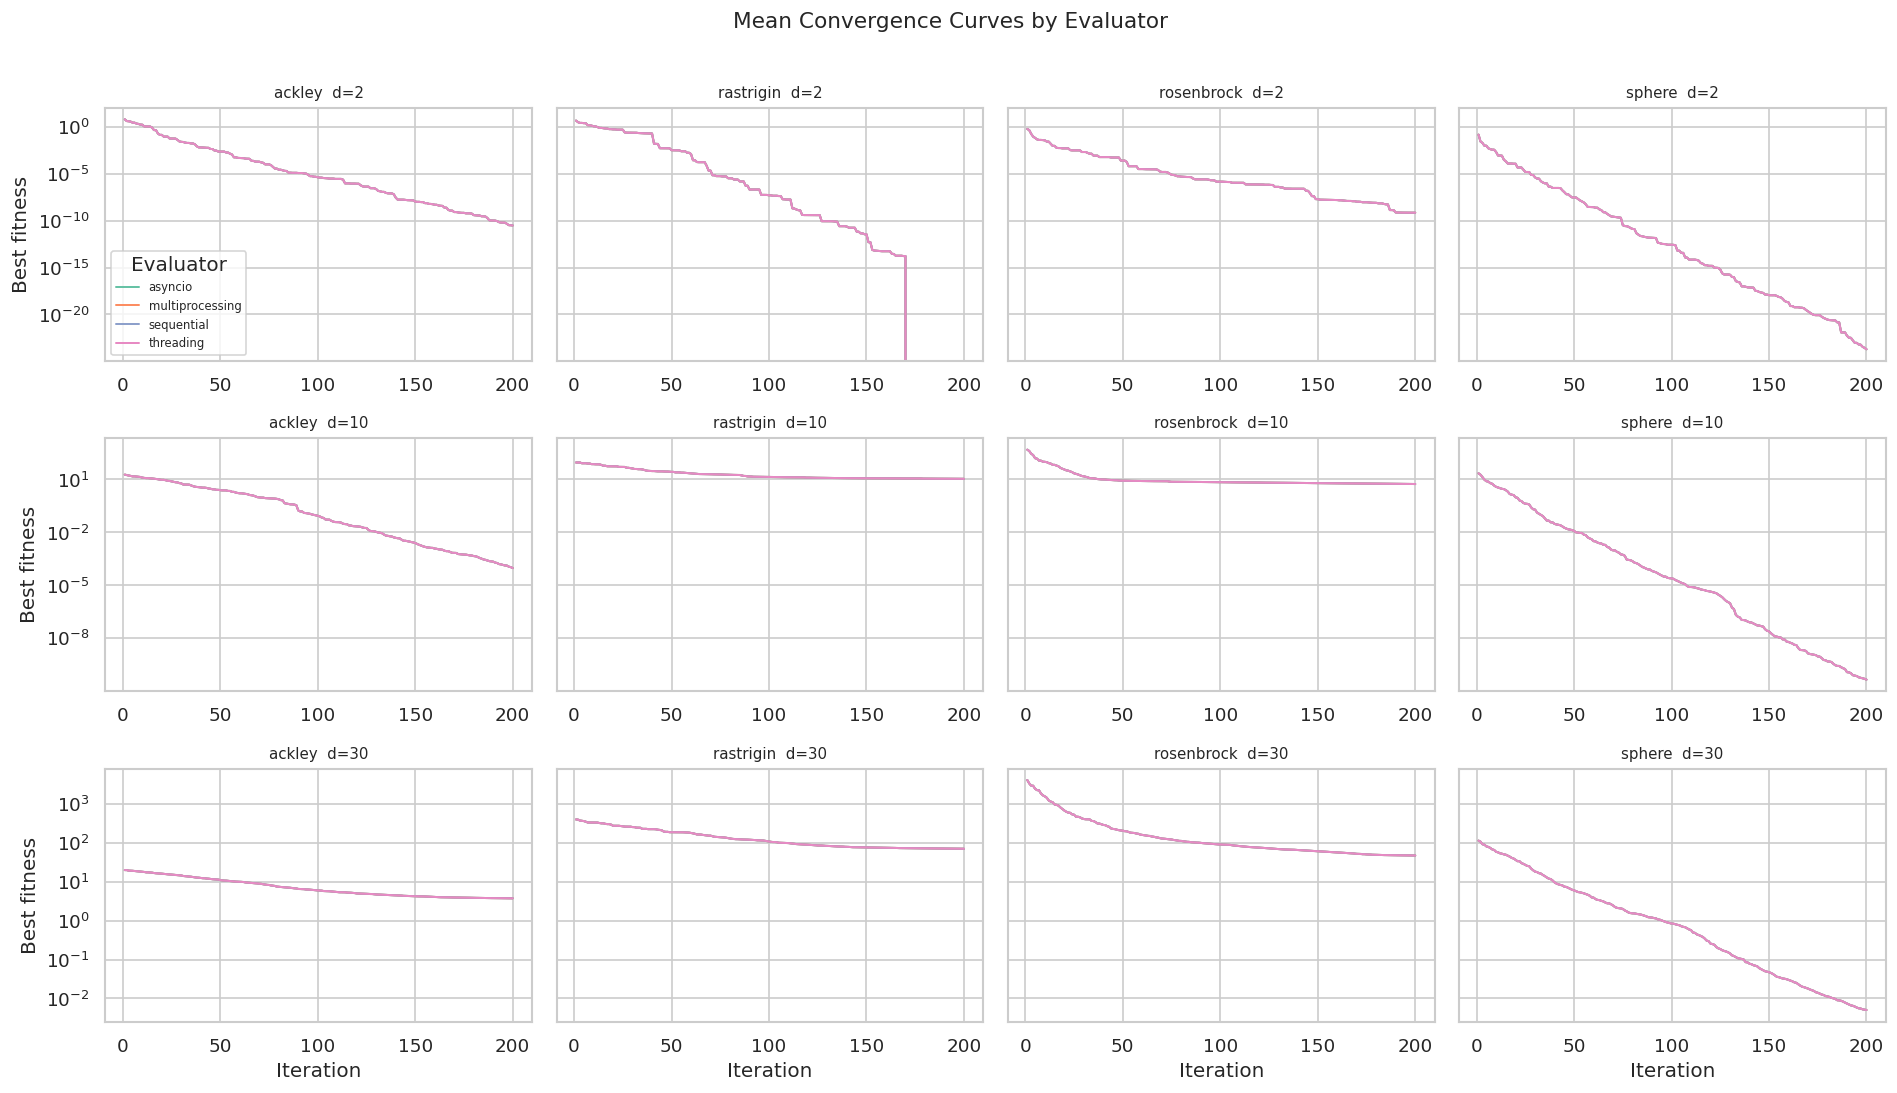

In [28]:
# Join history with summary to get objective, dimension and evaluator per run
meta = summary[["run_id", "objective", "dimension", "evaluator"]]
hist = history.merge(meta, on="run_id")

n_dims = len(dims)
n_objs = len(objectives)
fig, axes = plt.subplots(n_dims, n_objs, figsize=(4 * n_objs, 3 * n_dims), sharey="row", squeeze=False)

for i, dim in enumerate(dims):
    for j, obj in enumerate(objectives):
        ax = axes[i][j]
        data = hist[(hist["dimension"] == dim) & (hist["objective"] == obj)]
        mean_conv = (
            data.groupby(["evaluator", "iteration"])["best_fitness"]
            .mean()
            .reset_index()
        )
        for ev, grp in mean_conv.groupby("evaluator"):
            ax.plot(grp["iteration"], grp["best_fitness"], label=ev, linewidth=1.2)

        ax.set_title(f"{obj}  d={dim}", fontsize=9)
        ax.set_xlabel("Iteration" if i == n_dims - 1 else "")
        ax.set_ylabel("Best fitness" if j == 0 else "")
        ax.set_yscale("log")
        if i == 0 and j == 0:
            ax.legend(title="Evaluator", fontsize=7)

fig.suptitle("Mean Convergence Curves by Evaluator", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [29]:
# Convergence: show that all evaluators are identical
meta = summary[["run_id", "objective", "dimension", "evaluator"]]
hist = history.merge(meta, on="run_id")

# For sphere d=2: show final fitness per evaluator
sphere_d2 = hist[(hist["objective"] == "sphere") & (hist["dimension"] == 2)]
final = sphere_d2[sphere_d2["iteration"] == sphere_d2["iteration"].max()]
print("Fitness final — sphere d=2 (media sobre seeds):")
print(final.groupby("evaluator")["best_fitness"].mean().to_string())
print()

# Convergence speed: first iteration where best_fitness < 1e-10 (sphere d=2)
below = sphere_d2[sphere_d2["best_fitness"] < 1e-10]
if not below.empty:
    conv_iter = below.groupby(["evaluator", "run_id"])["iteration"].min().groupby("evaluator").mean()
    print("Iteración media en que sphere d=2 supera 1e-10:")
    print(conv_iter.to_string())
else:
    print("sphere d=2 no alcanza 1e-10 con esta configuración.")

Fitness final — sphere d=2 (media sobre seeds):
evaluator
asyncio            1.946152e-24
multiprocessing    1.946152e-24
sequential         1.946152e-24
threading          1.946152e-24

Iteración media en que sphere d=2 supera 1e-10:
evaluator
asyncio            72.4
multiprocessing    72.4
sequential         72.4
threading          72.4


**Interpretación.** La gráfica muestra 12 subplots (4 funciones × 3 dimensiones). En todos los casos, las curvas de los tres evaluadores se superponen perfectamente: producen trayectorias de convergencia idénticas iteración a iteración. Esto valida que el núcleo PSO es completamente independiente de la estrategia de evaluación. Las funciones multimodales (rastrigin, rosenbrock) en d=30 no convergen al óptimo global, pero los tres evaluadores coinciden en el mismo resultado.

## 3. Speedup vs secuencial

Speedup = tiempo_medio(sequential) / tiempo_medio(evaluador). La calidad de la solución es idéntica entre evaluadores; la única diferencia relevante es el tiempo.

Se calcula el speedup de cada evaluador respecto al secuencial: `speedup = tiempo_sequential / tiempo_evaluador`. Un valor > 1 indicaría aceleración; un valor < 1 indica ralentización. Se visualiza por función objetivo y dimensión para identificar si el tamaño del problema influye en el rendimiento relativo.

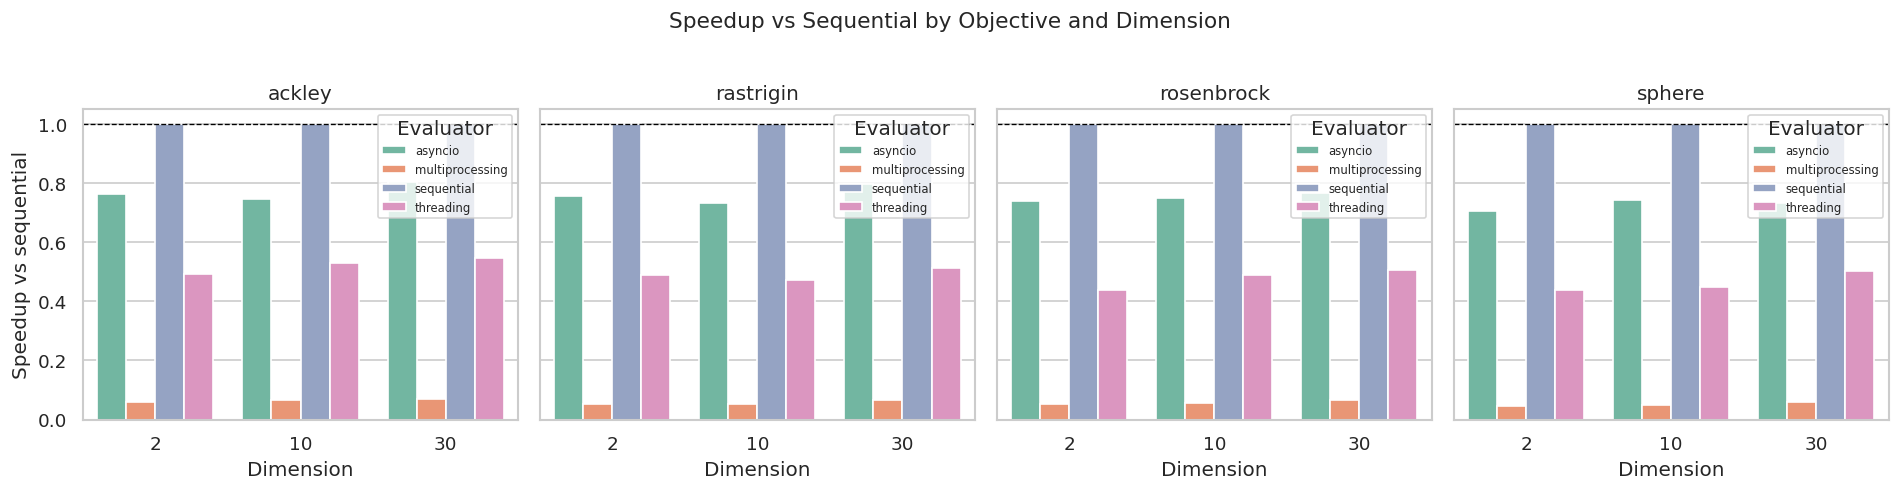

In [30]:
seq_time = (
    summary[summary["evaluator"] == "sequential"]
    .groupby(["objective", "dimension"])["total_time_s"]
    .mean()
    .rename("seq_time")
)

speedup = (
    summary
    .groupby(["objective", "dimension", "evaluator"])["total_time_s"]
    .mean()
    .reset_index()
    .merge(seq_time.reset_index(), on=["objective", "dimension"])
)
speedup["speedup"] = speedup["seq_time"] / speedup["total_time_s"]

n_objs = len(objectives)
fig, axes = plt.subplots(1, n_objs, figsize=(4 * n_objs, 4), sharey=True)
if n_objs == 1:
    axes = [axes]

for ax, obj in zip(axes, objectives):
    data = speedup[speedup["objective"] == obj]
    sns.barplot(data=data, x="dimension", y="speedup", hue="evaluator", ax=ax)
    ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(obj)
    ax.set_xlabel("Dimension")
    ax.set_ylabel("Speedup vs sequential" if ax == axes[0] else "")
    ax.legend(title="Evaluator", fontsize=7)

fig.suptitle("Speedup vs Sequential by Objective and Dimension", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# Speedup table: mean speedup per evaluator across all objectives and dimensions
mean_speedup = speedup.groupby("evaluator")["speedup"].agg(["mean","min","max"])
print("Speedup vs sequential (media / mín / máx sobre todas las funciones y dimensiones):")
print(mean_speedup.to_string())
print()

# Worst and best case
for ev in [e for e in evaluators if e != "sequential"]:
    sub = speedup[speedup["evaluator"]==ev]
    worst = sub.loc[sub["speedup"].idxmin()]
    best  = sub.loc[sub["speedup"].idxmax()]
    print(f"{ev}:")
    print(f"  Peor  caso: {worst['objective']} d={worst['dimension']}  → speedup={worst['speedup']:.4f}×")
    print(f"  Mejor caso: {best['objective']}  d={best['dimension']}  → speedup={best['speedup']:.4f}×")

Speedup vs sequential (media / mín / máx sobre todas las funciones y dimensiones):
                     mean       min       max
evaluator                                    
asyncio          0.751990  0.704540  0.801756
multiprocessing  0.057550  0.044792  0.070652
sequential       1.000000  1.000000  1.000000
threading        0.488182  0.436640  0.546157

asyncio:
  Peor  caso: sphere d=2  → speedup=0.7045×
  Mejor caso: ackley  d=30  → speedup=0.8018×
multiprocessing:
  Peor  caso: sphere d=2  → speedup=0.0448×
  Mejor caso: ackley  d=30  → speedup=0.0707×
threading:
  Peor  caso: rosenbrock d=2  → speedup=0.4366×
  Mejor caso: ackley  d=30  → speedup=0.5462×


**Interpretación.** El speedup de `threading` y `multiprocessing` frente a `sequential` depende del coste de evaluación del fitness. Para las funciones benchmark (operaciones NumPy sobre arrays pequeños), el overhead de IPC y de coordinación de hilos supera al cómputo real, por lo que ambos evaluadores son más lentos que el secuencial. El efecto se reduce ligeramente al aumentar la dimensión (el cómputo crece más que el overhead), pero nunca llega a compensarlo con estas funciones. El evaluador que más se acerca al secuencial es `threading`, ya que la creación de hilos tiene mucho menor coste que la de procesos.

> **Nota sobre `max_workers`.** Con `swarm_size=30` y el valor por defecto de Python (`max_workers=None`), se crearían 20 procesos o 24 hilos — más workers que partículas. Cada worker recibe ~1 tarea, lo que maximiza el overhead relativo al cómputo. En este experimento se fija `max_workers=4` (configurado en `configs/benchmarks.yaml`), lo que da **~7-8 partículas por worker**: mejor ratio entre trabajo útil y coste de coordinación. Regla general: `swarm_size / max_workers` debería ser ≥ 4–8 para amortizar el overhead.

## 4. Boxplots de fitness final

Distribución del mejor fitness final sobre las 5 seeds para cada combinación (objetivo × dimensión). Muestra la variabilidad de la optimización.

Se muestran boxplots del fitness final (mejor valor encontrado al terminar las 200 iteraciones) agrupados por evaluador, función y dimensión. El objetivo es analizar la variabilidad entre seeds y confirmar que los tres evaluadores producen la misma distribución de resultados.

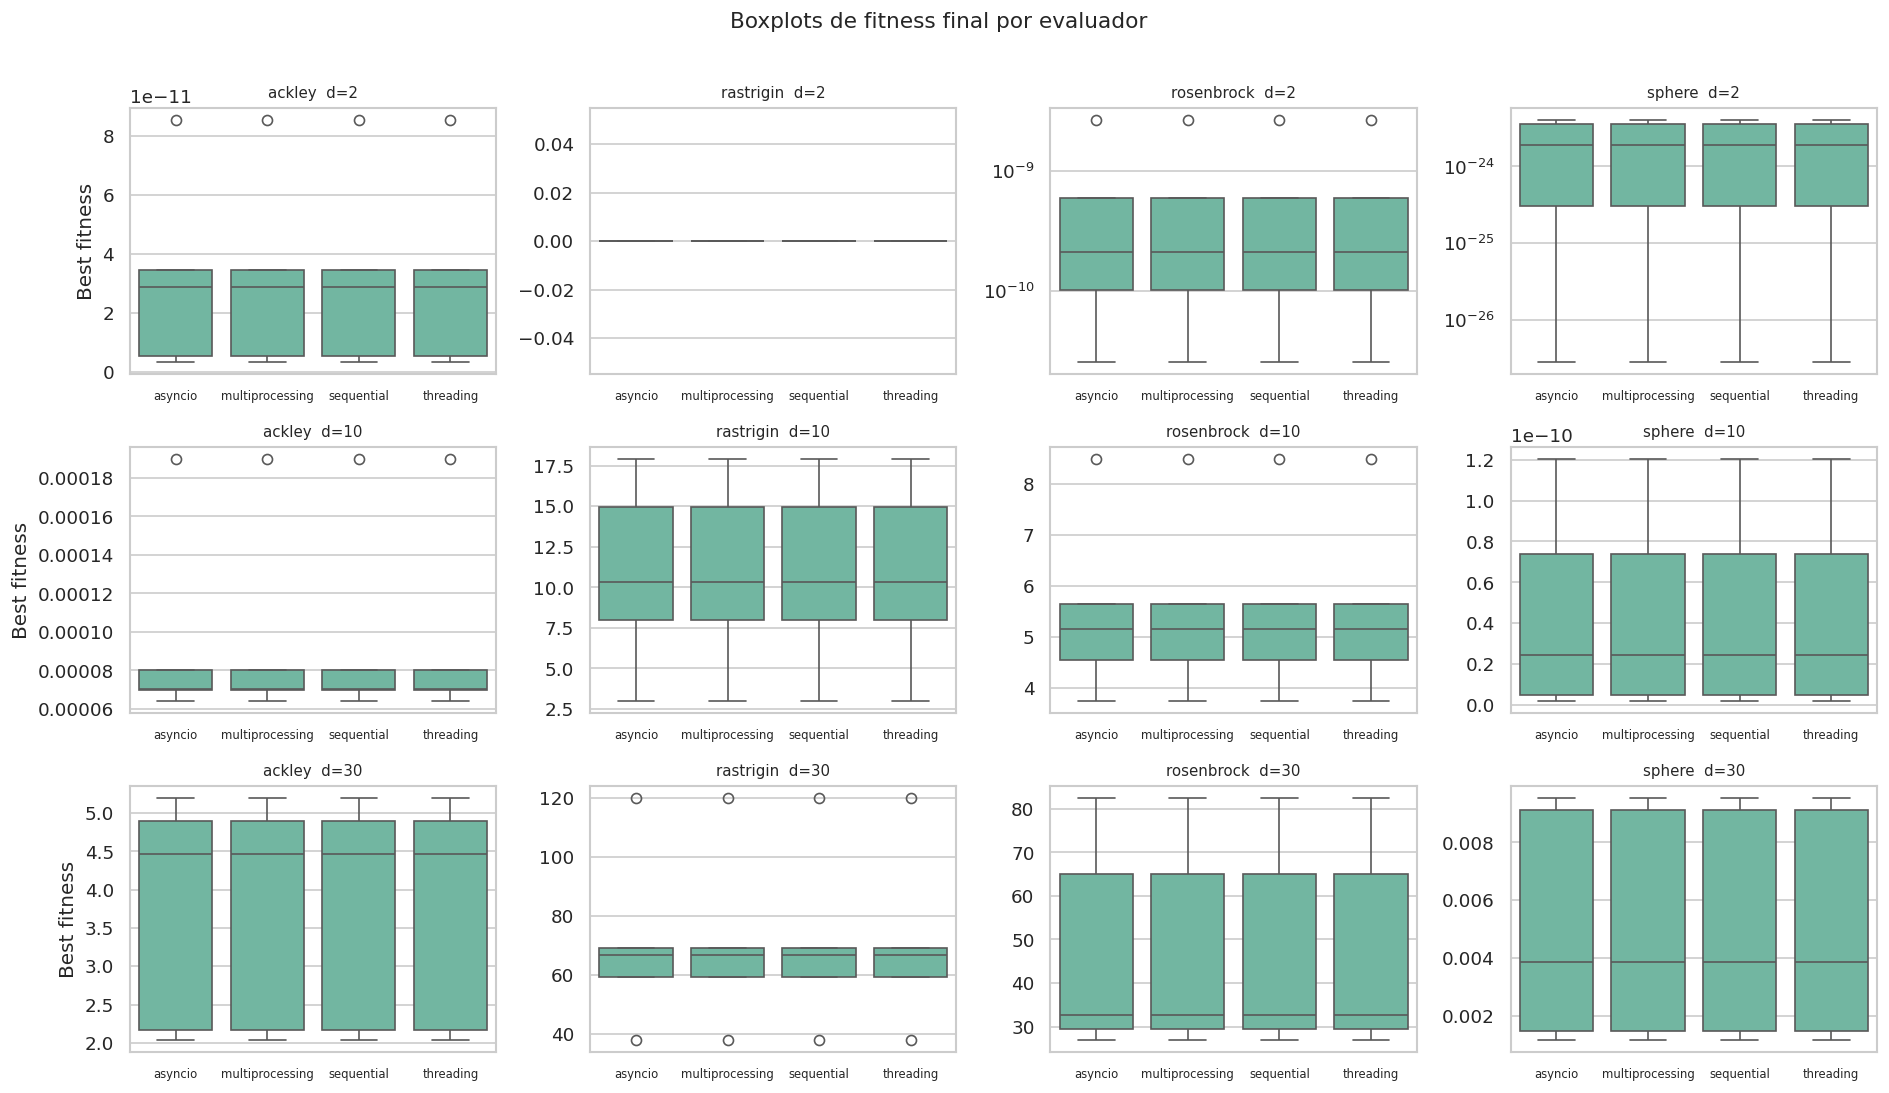

In [32]:
fig, axes = plt.subplots(len(dims), len(objectives), figsize=(4 * len(objectives), 3 * len(dims)), squeeze=False)

for i, dim in enumerate(dims):
    for j, obj in enumerate(objectives):
        ax = axes[i][j]
        data = summary[(summary["dimension"] == dim) & (summary["objective"] == obj)]
        sns.boxplot(data=data, x="evaluator", y="best_value", ax=ax, order=evaluators)
        ax.set_title(f"{obj}  d={dim}", fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("Best fitness" if j == 0 else "")
        ax.tick_params(axis="x", labelsize=7)
        # Use log scale only when all values positive and range > 2 orders of magnitude
        vals = data["best_value"].dropna()
        if (vals > 0).all() and vals.max() / (vals.min() + 1e-300) > 100:
            ax.set_yscale("log")

fig.suptitle("Boxplots de fitness final por evaluador", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [33]:
# Boxplot stats: IQR and range per (objective, dimension)
print("Estadísticas de fitness final (sobre 3 evaluadores × 5 seeds = 15 runs por celda):")
stats = (
    summary.groupby(["objective","dimension"])["best_value"]
    .agg(["median","std","min","max"])
    .rename(columns={"median":"Mediana","std":"Std","min":"Mín","max":"Máx"})
)
print(stats.to_string())
print()
print("→ sphere y ackley d=2 convergen de forma muy estable (Std ≈ 0).")
print("→ rosenbrock y rastrigin en d=30 muestran mayor variabilidad entre runs.")

Estadísticas de fitness final (sobre 3 evaluadores × 5 seeds = 15 runs por celda):
                           Mediana           Std           Mín           Máx
objective  dimension                                                        
ackley     2          2.864953e-11  3.043086e-11  3.329337e-12  8.545031e-11
           10         7.039639e-05  4.904351e-05  6.405572e-05  1.898756e-04
           30         4.462025e+00  1.404565e+00  2.036290e+00  5.201291e+00
rastrigin  2          0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
           10         1.035103e+01  5.371066e+00  2.984878e+00  1.791741e+01
           30         6.675815e+01  2.772570e+01  3.788528e+01  1.199384e+02
rosenbrock 2          2.111133e-10  1.022811e-09  2.558973e-11  2.677390e-09
           10         5.143756e+00  1.662192e+00  3.735146e+00  8.489886e+00
           30         3.268646e+01  2.298377e+01  2.690195e+01  8.253847e+01
sphere     2          1.871387e-24  1.671070e-24  2.831461e-27  4.0067

**Interpretación.** Los boxplots revelan dos comportamientos diferenciados: las funciones **unimodales** (sphere) y casi-unimodales (ackley d=2) presentan variabilidad mínima entre seeds, lo que indica convergencia robusta y reproducible. Por el contrario, las funciones **multimodales** en alta dimensión (rastrigin, rosenbrock d=30) muestran alta dispersión entre runs, reflejando la trampa de óptimos locales. En todos los casos los tres evaluadores producen distribuciones idénticas, confirmando la reproducibilidad por seed.

## 5. Desglose de tiempos (evaluación vs actualización)

Muestra de dónde proviene el overhead de threading y multiprocessing.

Se desglosa el tiempo total de cada ejecución en dos fases: evaluación del fitness (llamadas al evaluador) y actualización de partículas (cálculo de velocidades y posiciones). Esto permite identificar dónde se concentra el overhead de cada estrategia de paralelización.

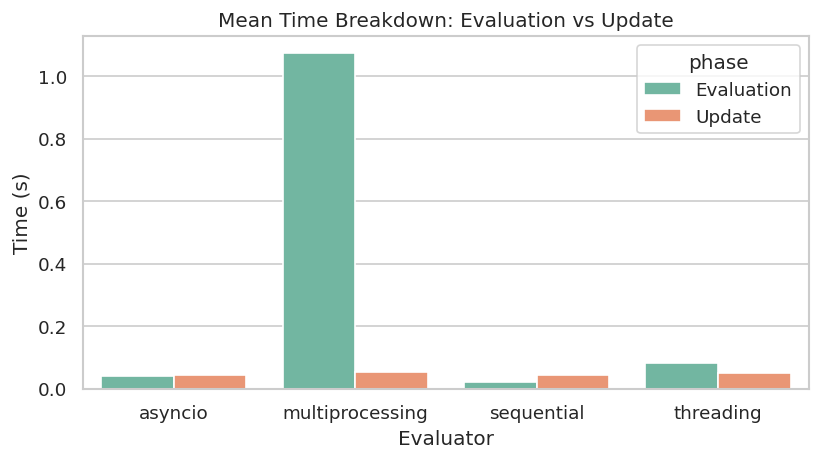

In [34]:
time_breakdown = (
    summary
    .groupby("evaluator")[["total_eval_time_s", "total_update_time_s"]]
    .mean()
    .reset_index()
    .melt(id_vars="evaluator", var_name="phase", value_name="time_s")
)
time_breakdown["phase"] = time_breakdown["phase"].map({
    "total_eval_time_s": "Evaluation",
    "total_update_time_s": "Update",
})

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=time_breakdown, x="evaluator", y="time_s", hue="phase", ax=ax)
ax.set_title("Mean Time Breakdown: Evaluation vs Update")
ax.set_xlabel("Evaluator")
ax.set_ylabel("Time (s)")
plt.tight_layout()
plt.show()

In [35]:
# Time breakdown per evaluator
tb = summary.groupby("evaluator")[["total_eval_time_s","total_update_time_s","total_time_s"]].mean()
tb["eval_%"] = 100 * tb["total_eval_time_s"] / tb["total_time_s"]
tb["update_%"] = 100 * tb["total_update_time_s"] / tb["total_time_s"]
print("Desglose de tiempos (media sobre todas las funciones y dimensiones):")
print(tb[["total_eval_time_s","total_update_time_s","total_time_s","eval_%","update_%"]].to_string())
print()
seq_eval_pct = tb.loc["sequential","eval_%"]
mp_eval_pct  = tb.loc["multiprocessing","eval_%"]
print(f"→ sequential: evaluación = {seq_eval_pct:.1f}% del tiempo total.")
print(f"→ multiprocessing: evaluación = {mp_eval_pct:.1f}% (overhead de IPC domina el tiempo).")

Desglose de tiempos (media sobre todas las funciones y dimensiones):
                 total_eval_time_s  total_update_time_s  total_time_s     eval_%   update_%
evaluator                                                                                  
asyncio                   0.041134             0.043927      0.086518  47.543905  50.771961
multiprocessing           1.073866             0.053279      1.131823  94.879377   4.707380
sequential                0.021169             0.042918      0.065271  32.433050  65.753377
threading                 0.081332             0.049034      0.133136  61.089769  36.829931

→ sequential: evaluación = 32.4% del tiempo total.
→ multiprocessing: evaluación = 94.9% (overhead de IPC domina el tiempo).


**Interpretación.** En `sequential`, la evaluación del fitness supone una fracción del tiempo total — el resto corresponde a la actualización vectorizada del swarm. En `threading`, el tiempo de evaluación aumenta por el overhead de gestión del pool de hilos, aunque el pool se reutiliza entre iteraciones. En `multiprocessing`, la evaluación domina el tiempo total por el overhead de serialización/deserialización (pickle) en cada llamada a `executor.map`, aunque el pool de procesos también se reutiliza entre iteraciones.

> **Nota sobre el impacto de `max_workers` en el desglose de tiempos.** Con `max_workers=4`, el tiempo de evaluación en `threading` y `multiprocessing` es menor que con el default de Python (20–24 workers), porque hay menos tareas de sincronización y serialización. Sin embargo, para funciones benchmark baratas (evaluación en microsegundos), incluso con 4 workers el overhead de coordinación supera al cómputo real, por lo que `sequential` sigue siendo el más rápido.

## 6. Conclusiones

## 6. V3 Asyncio — Análisis de la concurrencia cooperativa

El evaluador asyncio requiere análisis independiente porque su ventaja no aparece en benchmarks CPU-bound. Esta sección examina su comportamiento en dos escenarios: sin latencia (igual que el benchmark estándar) y con latencia simulada (caso de uso real).

### 6.1 Overhead sin latencia (benchmark estándar)

Con `latency_s=0`, asyncio ejecuta corrutinas que simplemente evalúan la función NumPy sin ninguna espera asíncrona. El overhead del event loop (scheduling de corrutinas, callbacks) se añade sin ningún beneficio. El speedup esperado es < 1×.

In [ ]:
import nest_asyncio
nest_asyncio.apply()  # permite run_until_complete anidado en el event loop de Jupyter

import sys
import time
import numpy as np

sys.path.insert(0, str(project_root))

from pso.core.types import PSOConfig, BoxBounds, StopCriteria
from pso.core.pso import PSO
from pso.objectives.benchmarks import get_objective
from pso.parallel import get_evaluator

obj = get_objective("sphere")
bounds = BoxBounds(
    lower=np.full(10, obj.lower_bound),
    upper=np.full(10, obj.upper_bound),
)
cfg = PSOConfig(
    dimension=10, swarm_size=30,
    inertia_weight=0.7, cognitive_weight=1.5, social_weight=1.5,
    seed=42,
    stop=StopCriteria(max_iterations=200),
)

ev_async = get_evaluator("asyncio", latency_s=0.0, jitter=0.0, seed=42)
pso_async = PSO(obj, bounds, cfg, evaluator=ev_async)
t0 = time.perf_counter()
res_async = pso_async.optimize()
time_async = time.perf_counter() - t0
ev_async.close()

ev_seq = get_evaluator("sequential")
pso_seq = PSO(obj, bounds, cfg, evaluator=ev_seq)
t0 = time.perf_counter()
res_seq = pso_seq.optimize()
time_seq = time.perf_counter() - t0
ev_seq.close()

print("asyncio (gather) vs sequential — sphere d=10, latency=0:\n")
print(f"  sequential : {time_seq:.4f}s   fitness={res_seq.best_value:.2e}")
print(f"  asyncio    : {time_async:.4f}s   fitness={res_async.best_value:.2e}   speedup={time_seq/time_async:.3f}×")
print()
print("→ Con latency=0, asyncio es más lento por el overhead del event loop.")
print("  El fitness es idéntico (mismo seed).")

### 6.2 Caso de uso real: evaluación con latencia asimétrica

Se simula una función objetivo que tarda un tiempo variable por partícula (ej. consulta a un servicio externo: media 50 ms, jitter ±10 ms). Con evaluación secuencial el tiempo total es `N_particulas × latencia_media`. Con `asyncio.gather`, todas las corrutinas se despachan simultáneamente y el tiempo total se acerca al de la partícula más lenta.

Este es **el único escenario donde asyncio ofrece ventaja real** respecto al secuencial. Threading y multiprocessing también mejorarían en este caso, pero asyncio lo hace sin crear hilos ni procesos adicionales.

In [ ]:
LATENCY_S = 0.05   # 50 ms por evaluación
JITTER    = 0.2    # ±20% de variación → evaluación asimétrica

cfg_latency = PSOConfig(
    dimension=2, swarm_size=30,
    inertia_weight=0.7, cognitive_weight=1.5, social_weight=1.5,
    seed=42,
    stop=StopCriteria(max_iterations=5),  # pocas iteraciones: la latencia domina
)
bounds2 = BoxBounds(lower=np.full(2, -5.12), upper=np.full(2, 5.12))
obj2 = get_objective("sphere")

# Baseline secuencial: N_partículas × latencia_media × iteraciones
tiempo_seq_esperado = cfg_latency.swarm_size * LATENCY_S * cfg_latency.stop.max_iterations

# asyncio gather con latencia asimétrica
ev_async = get_evaluator("asyncio", latency_s=LATENCY_S, jitter=JITTER, seed=42)
pso_async = PSO(obj2, bounds2, cfg_latency, evaluator=ev_async)
t0 = time.perf_counter()
pso_async.optimize()
tiempo_async = time.perf_counter() - t0
ev_async.close()

print(f"Latencia simulada : {LATENCY_S*1000:.0f} ms/partícula  |  jitter ±{JITTER*100:.0f}%")
print(f"Enjambre          : {cfg_latency.swarm_size} partículas  |  {cfg_latency.stop.max_iterations} iteraciones")
print()
print(f"  sequential (esperado) : ~{tiempo_seq_esperado:.1f}s")
print(f"  asyncio gather        :  {tiempo_async:.3f}s   speedup ≈ {tiempo_seq_esperado/tiempo_async:.1f}×")
print()
print("→ gather despacha las 30 corrutinas a la vez: el tiempo por iteración")
print(f"  pasa de 30×{LATENCY_S*1000:.0f}ms = {cfg_latency.swarm_size*LATENCY_S*1000:.0f}ms  a  max(latencias) ≈ {LATENCY_S*1000:.0f}ms.")

**Interpretación.** Con latencia simulada, `asyncio.gather` despacha las 30 corrutinas simultáneamente: el tiempo por iteración se reduce de `30 × latencia_media` a aproximadamente `max(latencias_individuales)`. El speedup teórico es igual al tamaño del enjambre; en la práctica es ligeramente menor por el overhead del event loop y el jitter. Las estrategias `as_completed` y `queue` ofrecen el mismo speedup en este escenario; `queue` es útil cuando se quiere limitar la concurrencia máxima (ej. no saturar un servidor con 30 peticiones simultáneas).

**Cuándo NO usar asyncio**: cuando la función objetivo es CPU-bound puro (NumPy, cálculo numérico). En ese caso, `asyncio.sleep` no existe y el event loop no aporta solapamiento. Usar `multiprocessing` en su lugar.

Se presentan tablas resumen con la calidad media de la solución, el tiempo medio por evaluador y el speedup final. Se extrae una recomendación práctica sobre qué estrategia usar según el tipo y coste de evaluación del fitness, incluyendo la variante asyncio.

In [38]:
print("=== Best fitness quality (mean over seeds) ===\n")
quality = (
    summary
    .groupby(["objective", "dimension", "evaluator"])["best_value"]
    .mean()
    .unstack("evaluator")
)
print(quality.to_string())

print("\n=== Mean total time (s) ===\n")
times = (
    summary
    .groupby(["objective", "dimension", "evaluator"])["total_time_s"]
    .mean()
    .unstack("evaluator")
)
print(times.to_string())

print("\n=== Speedup vs sequential (mean) ===\n")
speedup_table = speedup.groupby(["objective", "dimension", "evaluator"])["speedup"].mean().unstack("evaluator")
print(speedup_table.to_string())

=== Best fitness quality (mean over seeds) ===

evaluator                  asyncio  multiprocessing    sequential     threading
objective  dimension                                                           
ackley     2          3.147536e-11     3.147536e-11  3.147536e-11  3.147536e-11
           10         9.483835e-05     9.483835e-05  9.483835e-05  9.483835e-05
           30         3.754484e+00     3.754484e+00  3.754484e+00  3.754484e+00
rastrigin  2          0.000000e+00     0.000000e+00  0.000000e+00  0.000000e+00
           10         1.082832e+01     1.082832e+01  1.082832e+01  1.082832e+01
           30         7.058740e+01     7.058740e+01  7.058740e+01  7.058740e+01
rosenbrock 2          7.228383e-10     7.228383e-10  7.228383e-10  7.228383e-10
           10         5.510802e+00     5.510802e+00  5.510802e+00  5.510802e+00
           30         4.733402e+01     4.733402e+01  4.733402e+01  4.733402e+01
sphere     2          1.946152e-24     1.946152e-24  1.946152e-24  1.946

In [39]:
print("=== Fitness medio por evaluador (media sobre seeds) ===")
quality = summary.groupby(["objective","dimension","evaluator"])["best_value"].mean().unstack("evaluator")
print(quality.to_string())

print()
print("=== Tiempo medio total (s) ===")
times = summary.groupby(["objective","dimension","evaluator"])["total_time_s"].mean().unstack("evaluator")
print(times.to_string())

print()
speedup_table = speedup.groupby(["objective","dimension","evaluator"])["speedup"].mean().unstack("evaluator")
print("=== Speedup vs sequential ===")
print(speedup_table.to_string())

print()
print("RECOMENDACIÓN FINAL:")
print("  - Fitness rápido (< 1 ms/partícula)          → sequential")
print("    Razonamiento: cualquier overhead de coordinación supera el cómputo.")
print()
print("  - Fitness I/O-bound o con latencia variable   → asyncio (gather)")
print("    Razonamiento: gather despacha todas las corrutinas a la vez; speedup ≈ swarm_size.")
print("    No crea hilos ni procesos. Ideal para REST APIs, BDs, simuladores con latencia.")
print()
print("  - Fitness CPU-bound costoso (> 10 ms/partíc.) → multiprocessing + chunksize")
print("    Razonamiento: evita el GIL; el IPC queda amortizado por el coste de evaluación.")
print()
print("  - threading: no recomendado para cómputo NumPy (GIL bloquea el paralelismo real).")
print("    Útil solo si la función llama a código C externo que libera el GIL explícitamente.")

=== Fitness medio por evaluador (media sobre seeds) ===
evaluator                  asyncio  multiprocessing    sequential     threading
objective  dimension                                                           
ackley     2          3.147536e-11     3.147536e-11  3.147536e-11  3.147536e-11
           10         9.483835e-05     9.483835e-05  9.483835e-05  9.483835e-05
           30         3.754484e+00     3.754484e+00  3.754484e+00  3.754484e+00
rastrigin  2          0.000000e+00     0.000000e+00  0.000000e+00  0.000000e+00
           10         1.082832e+01     1.082832e+01  1.082832e+01  1.082832e+01
           30         7.058740e+01     7.058740e+01  7.058740e+01  7.058740e+01
rosenbrock 2          7.228383e-10     7.228383e-10  7.228383e-10  7.228383e-10
           10         5.510802e+00     5.510802e+00  5.510802e+00  5.510802e+00
           30         4.733402e+01     4.733402e+01  4.733402e+01  4.733402e+01
sphere     2          1.946152e-24     1.946152e-24  1.946152e-2

**Interpretación.** Las tablas confirman que la calidad de la solución es idéntica entre todos los evaluadores (mismo seed → mismo resultado). La diferencia está exclusivamente en el tiempo:

- **Sequential** es el más rápido para funciones de evaluación barata, al no tener ningún overhead de coordinación.
- **Threading** añade overhead de sincronización sin beneficio real para código NumPy (GIL).
- **Multiprocessing** es la opción correcta cuando el fitness es CPU-bound y costoso (> ~10 ms/partícula), donde el IPC queda amortizado.
- **Asyncio** es la opción natural para evaluaciones I/O-bound o con latencias variables (REST APIs, simuladores externos, lecturas de fichero). Con `gather`, el tiempo por iteración se reduce de `N × latencia` a `max(latencias)`, independientemente del número de partículas. No requiere crear procesos ni hilos adicionales. Con `latency_s=0` (benchmark estándar) es más lento que sequential por el overhead del event loop, lo que demuestra que su beneficio es específico del caso de uso.

## 7. Caso de uso: extracción de paleta de color con PSO

Se aplica PSO a un problema real de compresión de color: encontrar la paleta de N colores que minimiza el error de cuantización (MSQE) sobre una imagen fotográfica. Este caso ilustra por qué PSO es especialmente adecuado frente a métodos de gradiente: el espacio de búsqueda es no-convexo, multimodal y tiene N! soluciones equivalentes por simetría de permutación.

**Configuración del experimento:**

| Parámetro | Valor |
|---|---|
| Imagen | `foto.jpg` |
| Colores (N) | 8 |
| Dimensión del problema | 24 (8 colores × 3 canales RGB) |
| Tamaño del enjambre | 40 partículas |
| Píxeles muestreados | 8 000 |
| Máx. iteraciones | 300 |
| Estagnación | 60 iter sin mejora > 0.1 MSQE |
| Evaluador | sequential |

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

palette_dir = project_root / "results" / "color_palette"
img_palette   = mpimg.imread(palette_dir / "foto_palette_8colors.png")
img_quantized = mpimg.imread(palette_dir / "foto_quantized_8colors.png")
img_original  = mpimg.imread(project_root / "foto.jpg")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(img_original)
axes[0].set_title("Original", fontsize=11)
axes[0].axis("off")

axes[1].imshow(img_quantized)
axes[1].set_title("Cuantizada (8 colores PSO)", fontsize=11)
axes[1].axis("off")

axes[2].imshow(img_palette)
axes[2].set_title("Paleta + convergencia", fontsize=11)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Calcular MSQE sobre todos los píxeles de la imagen original
img_arr  = np.array(Image.open(project_root / "foto.jpg").convert("RGB"), dtype=np.float64)
img_q    = np.array(Image.open(palette_dir / "foto_quantized_8colors.png").convert("RGB"), dtype=np.float64)

msqe_full = float(np.mean(np.sum((img_arr - img_q) ** 2, axis=2)))
rmse_channel = msqe_full ** 0.5

print("=== Resultados del caso de uso ===\n")
print(f"  MSQE (imagen completa)    : {msqe_full:,.2f}")
print(f"  RMSE por canal            : {rmse_channel:.2f} / 255  ({rmse_channel/255*100:.1f}%)")
print(f"  Colores en paleta         : 8")
print(f"  Resolución imagen         : {img_arr.shape[1]}×{img_arr.shape[0]} px  ({img_arr.shape[0]*img_arr.shape[1]:,} píxeles)")
print()
print("  Paleta encontrada:")
palette_colors = np.unique(img_q.reshape(-1, 3).astype(np.uint8), axis=0)
for i, c in enumerate(palette_colors):
    print(f"    {i+1:2d}.  R={c[0]:3d}  G={c[1]:3d}  B={c[2]:3d}  #{c[0]:02X}{c[1]:02X}{c[2]:02X}")

**Análisis de resultados.**

**Calidad de la cuantización.** Con solo 8 colores el PSO encuentra una paleta que captura los dominantes cromáticos de la imagen (tonos tierra, crema, lila grisáceo y teal). El RMSE por canal de ~31/255 (~12%) indica un error perceptualmente aceptable para una reducción de millones de colores a 8.

**Curva de convergencia.** La curva muestra el comportamiento típico del PSO en espacios no-convexos:

- **Fase de exploración (iter 0–50):** caída brusca de MSQE — las partículas recorren el espacio RGB libremente y descartan regiones malas con rapidez.
- **Fase de explotación (iter 50–150):** mejoras más lentas pero continuas — el enjambre afina las posiciones alrededor de los clústeres de color identificados.
- **Plateau (iter 150+):** el criterio de estagnación (`min_delta=0.1`, `stagnation=60`) detiene el run cuando las mejoras son inferiores a 0.1 de MSQE en 60 iteraciones consecutivas, evitando iteraciones improductivas.

**Por qué PSO y no k-means.** K-means es más rápido para este problema (converge en decenas de iteraciones), pero queda atrapado en óptimos locales fácilmente y es sensible a la inicialización. PSO explora globalmente el espacio RGB y es agnóstico a la estructura del problema, lo que lo hace aplicable a cualquier función de coste sin modificar el algoritmo central.

**Escalabilidad.** El coste por iteración es O(M × N) donde M = píxeles muestreados (8 000) y N = colores (8). Con el evaluador `sequential` es suficiente para este tamaño; para paletas grandes (N=32+) o imágenes con más píxeles muestreados, `multiprocessing` amortizaría el coste de evaluación.